Data Loading and Exploration

In [1]:
import sys
!{sys.executable} -m pip install wradlib

In [2]:
import wradlib as wrl
print(wrl.__version__)

2.9.5


shape: (1200, 1100)
range: 0.0 to 80.0 dBZ
Timestep: 2026-08-21 10:45:00


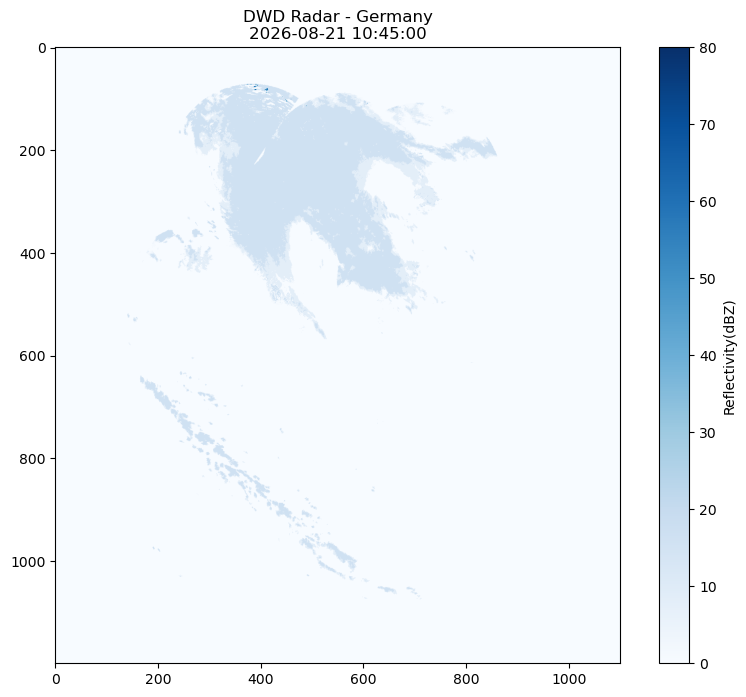

In [3]:
import wradlib as wrl
import numpy as np
import matplotlib.pyplot as plt
import cv2

#Load one radar file
data, metadata = wrl.io.read_radolan_composite(
    'C:/Users/marga/projects/DWD-radar/HG_LATEST_000'
)
print(f"shape: {data.shape}")
print(f"range: {data.min():.1f} to {data.max():.1f} dBZ")
print(f"Timestep: {metadata['datetime']}")

plt.figure(figsize=(10, 8))
plt.imshow(data, cmap='Blues', vmin=0, vmax=80)
plt.colorbar(label='Reflectivity(dBZ)')
plt.title(f"DWD Radar - Germany\n{metadata['datetime']}")
plt.savefig('raw_radar.png', dpi=150)
plt.show()


Marshall - Palmer Conversion

Pixels with precipitation: 138544
25th percentile: 0.365 mm/hr
75th percentile: 0.365 mm/hr
95th percentile: 0.365 mm/hr
99th percentile: 0.365 mm/hr


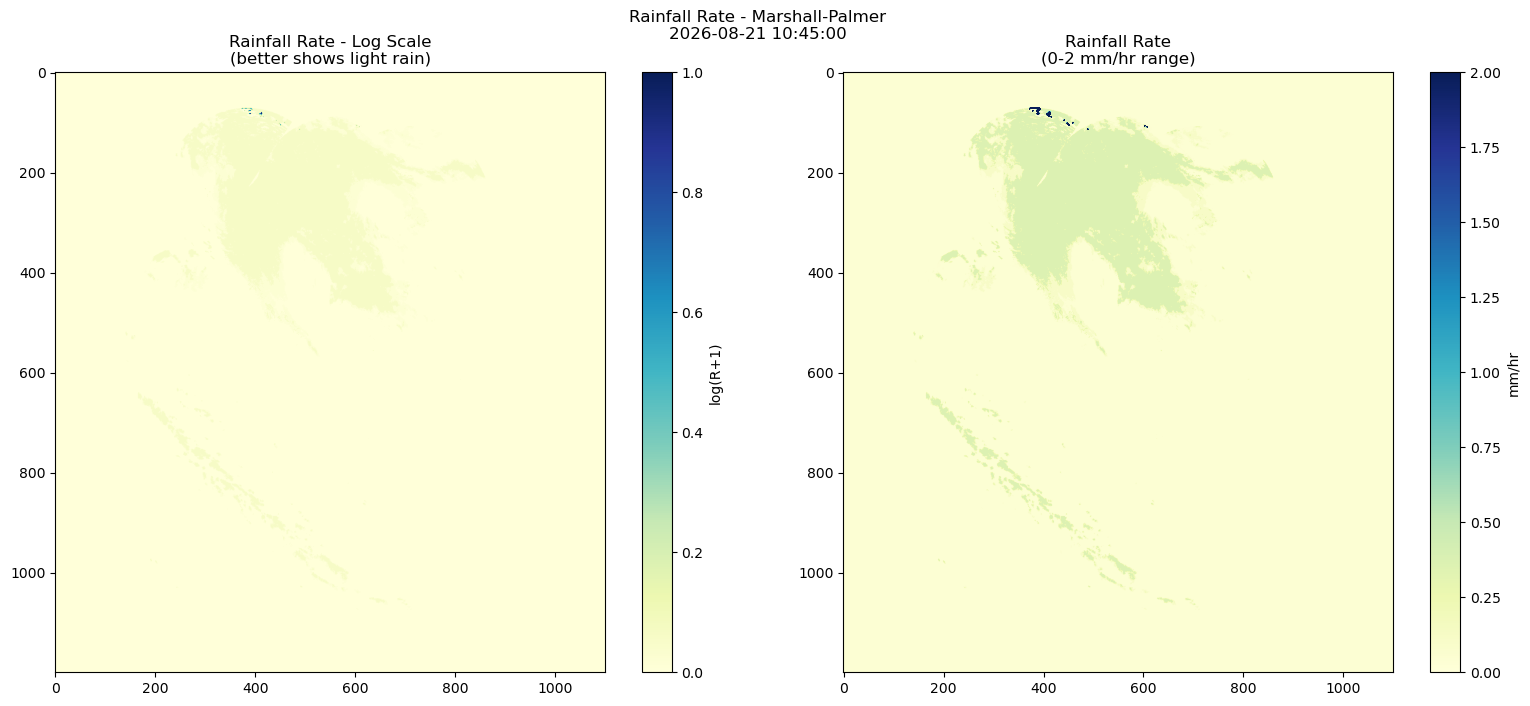

In [4]:
# Handle no data values
nodata = metadata['nodataflag']
data_clean = data.copy()
data_clean[data_clean == nodata] = 0.0
data_clean[data_clean < 0] = 0.0

#Marshall-Palmer figured out the relationship between radar reflectivity(dBZ) and rainfall rate(mm/hour)
Z = 10 ** (data_clean / 10)
R = np.where(Z > 0, (Z / 200) ** (1/1.6), 0)

# Cap at physically realistic maximum
# 100 mm/hr is already extreme rainfall - anything above is likely clutter or hail
R = np.clip(R, 0, 100)

R_nonzero = R[R > 0.05]
print(f"Pixels with precipitation: {len(R_nonzero)}")
print(f"25th percentile: {np.percentile(R_nonzero, 25):.3f} mm/hr")
print(f"75th percentile: {np.percentile(R_nonzero, 75):.3f} mm/hr")
print(f"95th percentile: {np.percentile(R_nonzero, 95):.3f} mm/hr")
print(f"99th percentile: {np.percentile(R_nonzero, 99):.3f} mm/hr")

# Plot with better colorscale
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left - log scale to see variation
axes[0].imshow(np.log1p(R), cmap='YlGnBu')
axes[0].set_title('Rainfall Rate - Log Scale\n(better shows light rain)')
axes[0].figure.colorbar(
    plt.cm.ScalarMappable(cmap='YlGnBu'),
    ax=axes[0], label='log(R+1)'
)

# Right - clipped to 5 mm/hr to see light rain detail
axes[1].imshow(R, cmap='YlGnBu', vmin=0, vmax=2)
axes[1].set_title('Rainfall Rate\n(0-2 mm/hr range)')
axes[1].figure.colorbar(
    plt.cm.ScalarMappable(
        norm=plt.Normalize(0, 2),
        cmap='YlGnBu'
    ),
    ax=axes[1], label='mm/hr'
)
plt.suptitle(f"Rainfall Rate - Marshall-Palmer\n{metadata['datetime']}")
plt.tight_layout()
plt.savefig('rainfall_rate.png', dpi=150)
plt.show()








OpenCV Preprocessing

Original data range: 0 to 255
Blurred data range: 0 to 177
Edge pixels detected: 14,051
Contours: 483
Significant storm cells: 18


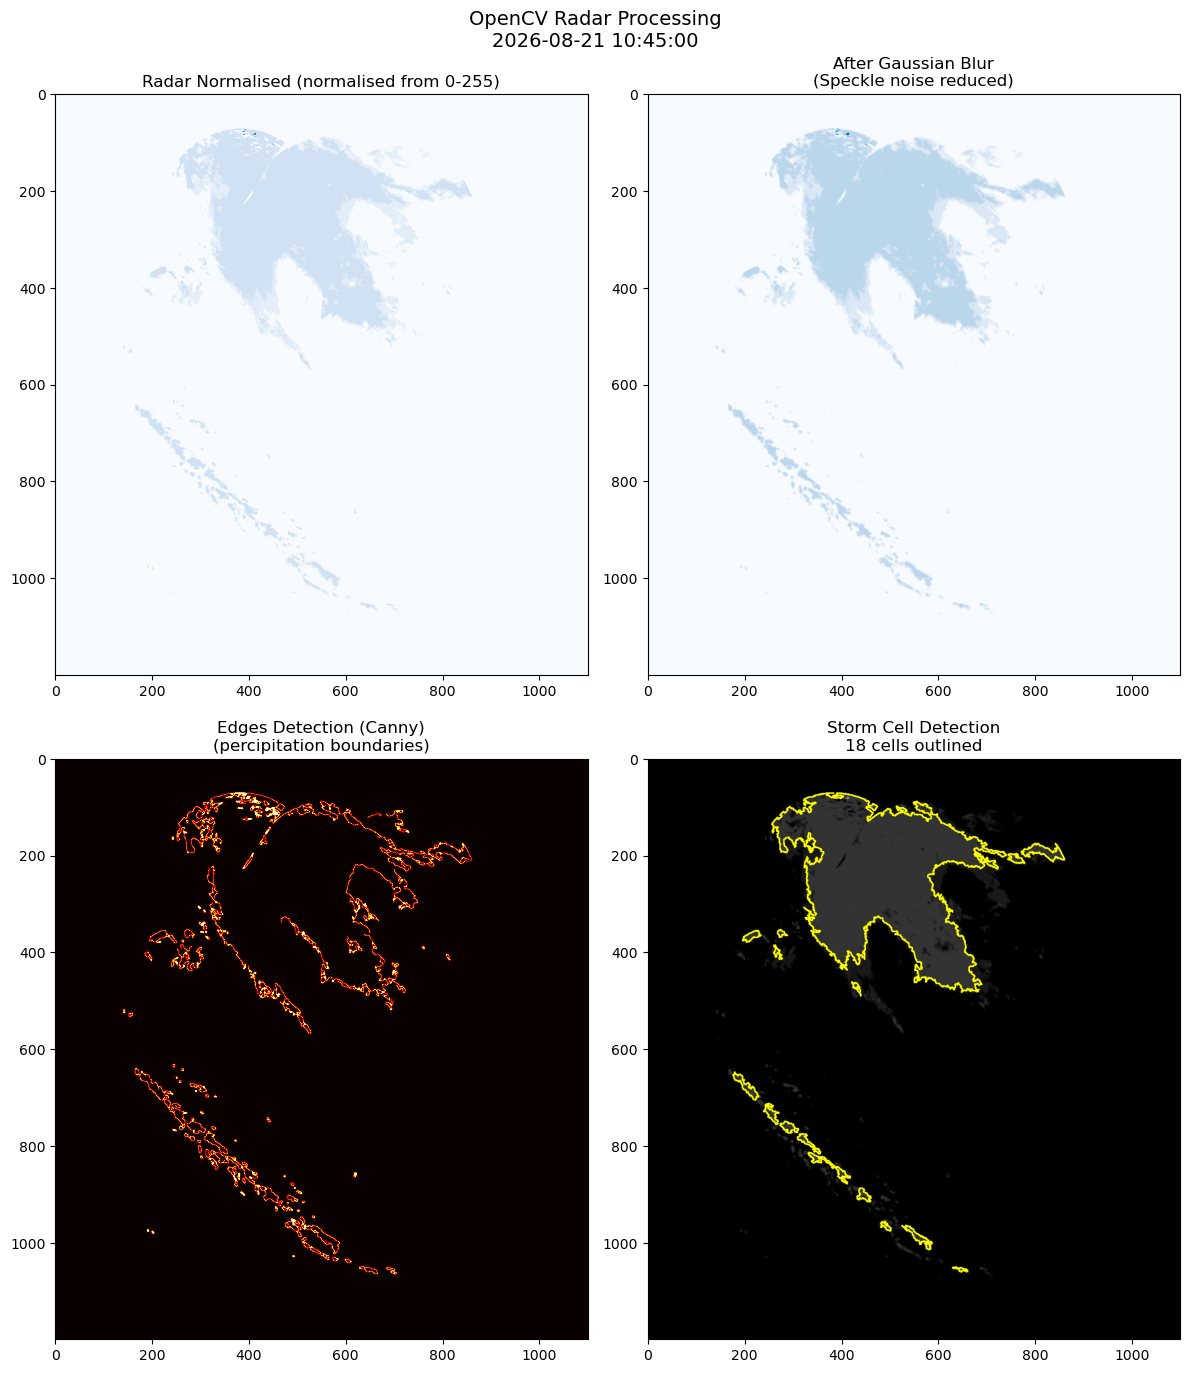

In [5]:
import cv2

# convert radar data into uint8 for OpenCV
# OpenCV expects 0-255

data_uint8 = ((data_clean / 80) * 255).astype(np.uint8) # radar data ranges from 0-80 dBZ e.g 0 dBZ /  80 = 0.0, 80 dBZ / 80 = 1.0, then scale to 255, then convert to uint8 for openCv

# Step 1: Gaussian Blur  - reduce radar speckle noise
# We need to reduce radar speckle noise(random noise from ground clutter)
# Gaussian blur smooths this without destroying the percipitation patterns
# (5, 5) - Kernel size
blurred = cv2.GaussianBlur(
    data_uint8, 
    (5, 5), 
    0
)
print(f"Original data range: {data_uint8.min()} to {data_uint8.max()}") # whats the original images opencv range
print(f"Blurred data range: {blurred.min()} to {blurred.max()}") # whats the opencv images after gaussian filter range

# Step 2: Edge Detection - find percipitation boundaries
# Canny helps find sharp transitions areas of rain and no-rain
edges = cv2.Canny(blurred, threshold1=30, threshold2=100)
print(f"Edge pixels detected: {(edges > 0).sum():,}") # count all pixels where edges are greater than zero, format with commas, print it.

# Step 3: Morphological operations - clean up noise
# Use dilation and erosion
# Dilation connects nearby edges to complete boundaries
# Erosion removes isolated single pixels (ground clutter artifacts)
'''
Weather systems are circular or oval shaped - storm cells, rain bands, fronts. 
An elliptical kernel preserves these natural rounded shapes better than a square rectangle kernel which would add artificial corners.
Dilation expands bright pixels outward using the kernel shape - connects nearby edge fragments into complete boundaries.
Erosion shrinks bright pixels inward - removes isolated single pixel noise.
Together they are called morphological closing - it closes small gaps in edge lines while removing isolated noise pixels.

For radar specifically:

Dilation connects edge fragments at storm cell boundaries that Canny broke into pieces
Erosion removes single pixel ground clutter artifacts

Result is clean continuous outlines around precipitation zones.

'''
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
edges_dilated = cv2.dilate(edges, kernel, iterations=1)
edges_clean = cv2.erode(edges_dilated, kernel, iterations=1)

# Step 4: Contour detection - outline storm cells
# Find connected regions of percipitation

'''
Binary mask (precipitation yes/no)
        ↓
findContours traces boundaries
        ↓
Returns list of boundary point arrays
        ↓
Filter by area > 100 pixels
        ↓
significant_contours = real storm cells
        ↓
Draw on radar image with cv2.drawContours

data converted to 0-255 scale, 30 corresponds roughly to dBZ values above noise level - actual precipitation rather than ground clutter.
Creates boolean array - True where radar value is above 30, False elsewhere
RETR_EXTERNAL - controls which contours are retrieved

OPTIONS: 
RETR_EXTERNAL - ONLY OUTERMOST CONTOURS
cv2.RETR_LIST - all contours, no hierachy
RETR_TREE - all contours with full hierarchy 
Storm cell with a gap inside:

  ████████
  █      █
  █ gap  █   RETR_EXTERNAL → only outer boundary traced
  █      █   RETR_TREE     → outer boundary + inner hole boundary
  ████████

CHAIN_APPROX_SIMPLE - controls how contour points are stored
OPTIONS:
cv2.CHAIN_APPROX_NONE - stores every single pixel on the boundary
cv2.CHAIN_APPROX_SIMPLE - store only corner points,skip redundant ones

Rectangle contour:

CHAIN_APPROX_NONE:    CHAIN_APPROX_SIMPLE:
* * * * *             *       *
*       *             
*       *             
*       *             
* * * * *             *       *
'''
contours, _ = cv2.findContours(
    (data_uint8 > 30).astype(np.uint8),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Filter small contours - minimum 100 pixel area
# Small contours are likely ground cluster not real precipitation
significant_contours = [c for c in contours if cv2.contourArea(c) > 100]
print(f"Contours: {len(contours)}")
print(f"Significant storm cells: {len(significant_contours)}")

# Step 5: Visualise OpenCV results
fig, axes = plt.subplots(2, 2, figsize=(12, 14))
fig.suptitle(f"OpenCV Radar Processing\n{metadata['datetime']}", fontsize=14)

'''
data_uint8 (grayscale)
        ↓
cvtColor GRAY2BGR → contour_img (colour but still looks grey)
        ↓
drawContours → draws green lines on storm cell boundaries
        ↓
cvtColor BGR2RGB → fix colour channels for matplotlib
        ↓
axes[1,1].imshow → display with correct green contours
'''
# raw normalised
axes[0,0].imshow(data_uint8, cmap='Blues')
axes[0,0].set_title('Radar Normalised (normalised from 0-255)')

axes[0,1].imshow(blurred, cmap='Blues')
axes[0,1].set_title('After Gaussian Blur\n(Speckle noise reduced)')

axes[1,0].imshow(edges_clean, cmap='hot')
axes[1,0].set_title('Edges Detection (Canny)\n(percipitation boundaries)')

# Contours overlaid on radar
contour_img = cv2.cvtColor(blurred, cv2.COLOR_GRAY2BGR)
cv2.drawContours(contour_img, significant_contours, -1, (0, 255, 255), 2)
axes[1,1].imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
axes[1,1].set_title(f'Storm Cell Detection\n{len(significant_contours)} cells outlined')

plt.tight_layout()
plt.savefig('opencv_processing.png', dpi=150)
plt.show()

Create Percipitation Labels

Based on actual dBZ values in this dataset

0           = no perciptation
1-8 dBZ     = very light (drizzle)
8-16 dBZ    = light rain
16-64 dBZ   = moderate rain
64+         = heavy rain / storm


Class Distributon: 
Class 0 (No rain): 1,174,447 pixels (89.0%)
Class 1 (Very light): 7,009 pixels (0.5%)
Class 2 (Light): 32,202 pixels (2.4%)
Class 3 (Moderate): 106,278 pixels (8.1%)
Class 4 (Heavy): 64 pixels (0.0%)


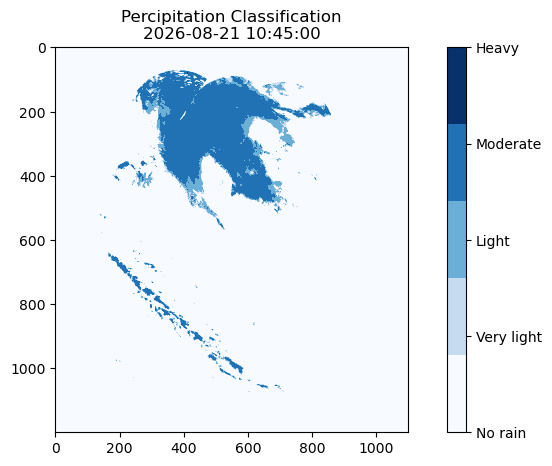

In [6]:
labels =  np.zeros(data_clean.shape, dtype=np.uint8)
labels[data_clean > 0] = 1 #very light
labels[data_clean >= 8] = 2 #light rain
labels[data_clean >= 16] = 3 #moderate rain
labels[data_clean >= 64] = 4 #heavy rain

# Check class distribution
unique, counts = np.unique(labels, return_counts=True)
total = labels.size
print("Class Distributon: ")
class_names = ['No rain', 'Very light', 'Light', 'Moderate', 'Heavy']
for cls, count in zip(unique, counts):
    print(f"Class {cls} ({class_names[cls]}): {count:,} pixels ({count/total*100:.1f}%)")

#Visualise labels
cmap = plt.colormaps['Blues'].resampled(5)
plt.figure(figsize=(10, 5))
plt.imshow(labels, cmap=cmap, vmin=0, vmax=4)
cbar = plt.colorbar(ticks=[0,1,2,3,4])
cbar.set_ticklabels(['No rain', 'Very light', 'Light', 'Moderate', 'Heavy'])
plt.title(f"Percipitation Classification\n{metadata['datetime']}")
plt.savefig('percipitation_labels.png', dpi=150)
plt.show()

Extract patches for CNN Training

In [7]:
# total number of patches to extract
'''
height steps = (1200-16)/8 = 148
width steps = (1100-16)/8 = 135
total steps = 148x135 = 19,980

1. set the patch size and stride
2. do the sliding window loop
3. Extract one patch
Full image (1200x1100):
┌─────────────────────────┐
│                         │
│    ┌──────┐             │
│    │16x16 │← one patch  │
│    │patch │             │
│    └──────┘             │
│         y,x             │
└─────────────────────────┘
4. Label the patch that was extracted
5. Collect patches and labels
6. convert those patches to numpy arrays
'''
PATCH_SIZE = 16
STRIDE = 8

patches = []
patch_labels = []

height, width = data_clean.shape

for y in range(0, height - PATCH_SIZE, STRIDE):
    for x in range(0, width - PATCH_SIZE, STRIDE):
        patch = data_clean[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

        # Label patch by its center pixel
        centre_label = labels[y + PATCH_SIZE//2, x + PATCH_SIZE//2]

        patches.append(patch)
        patch_labels.append(centre_label)

patches = np.array(patches) # Convert to numpy array
patch_labels = np.array(patch_labels)
print(f"Total patches: {len(patches)}")
print(f"Patch shape: {patches.shape}")
print(f"Label distribution:")

unique, counts = np.unique(patch_labels, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Class {cls} ({class_names[cls]}): {count:,} patches ({count/len(patch_labels)*100:.1f}%)")

Total patches: 20128
Patch shape: (20128, 16, 16)
Label distribution:
Class 0 (No rain): 17,868 patches (88.8%)
Class 1 (Very light): 108 patches (0.5%)
Class 2 (Light): 496 patches (2.5%)
Class 3 (Moderate): 1,654 patches (8.2%)
Class 4 (Heavy): 2 patches (0.0%)


Class Imbalance

In [8]:
'''
Class 0 (No rain): 1,174,447 pixels (89.0%)
Class 1 (Very light): 7,009 pixels (0.5%)
Class 2 (Light): 32,202 pixels (2.4%)
Class 3 (Moderate): 106,278 pixels (8.1%)
Class 4 (Heavy): 64 pixels (0.0%)
Because the classes are disproportionate, the class 0  is dominant(89.0%) and only 8.9% is moderate and 0% is heavy, 
the following things are done to balance the classes.

1. Merge Heavy with moderate 
2. Calculate the class weights for weighted loss
no rain:   1/17868 = 0.000056  ← very low weight
very light: 1/108  = 0.009259  ← higher weight
light:      1/496  = 0.002016  ← higher weight
moderate:   1/1656 = 0.000604  ← medium weight
The model pays more attention to rare classes during training.
3. Weighted loss
4. Weighted RandomSampler for balanced batches

'''
import torch
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

patch_labels_balanced = patch_labels.copy() # keep the original, put the duplicate(the change to be done) is patch_labels_balanced
patch_labels_balanced[patch_labels_balanced == 4] = 3

print("After merging Heavy into Moderate classes")
unique, counts = np.unique(patch_labels_balanced, return_counts=True)
class_names_merged = ['No rain', 'Very Light', 'Light', 'Moderate+Heavy']
for cls, count in zip(unique, counts):
    print(f" Class {cls} ({class_names_merged[cls]}): {count:,} patches ({count/len(patch_labels_balanced)*100:.1f}%)")

class_counts = np.array([counts[i] if i < len(counts) else 1 
                         for i in range(4)])
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()  # normalise to sum to 1
class_weights_tensor = torch.FloatTensor(class_weights)

print(f"\nClass weights for loss function:")
for cls, weight in enumerate(class_weights):
    print(f"  Class {cls} ({class_names_merged[cls]}): {weight:.4f}")

criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
print("\n Weighted CrossEntropyLoss created")

# Normalise patches to 0-1
patches_norm = patches.astype(np.float32) / 80.0  # divide by max dBZ
patches_tensor = torch.FloatTensor(patches_norm).unsqueeze(1)  # add channel dim
labels_tensor  = torch.LongTensor(patch_labels_balanced)
# PyTorch CrossEntropyLoss requires weights as a FloatTensor not a numpy array. This converts it.
print(f"\nPatches tensor shape: {patches_tensor.shape}")
print(f"Labels tensor shape:  {labels_tensor.shape}")

# Shows the final weight for each class so you can verify minority classes have higher weights.
sample_weights = class_weights[patch_labels_balanced]
sample_weights_tensor = torch.FloatTensor(sample_weights)

# Create dataset and dataloader
dataset = TensorDataset(patches_tensor, labels_tensor)

#Train\val split - 80/20
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size]
)
# After train/val split - create sampler using ONLY train indices
train_labels = labels_tensor[train_dataset.indices]
train_sample_weights = class_weights[train_labels.numpy()]
train_sample_weights_tensor = torch.FloatTensor(train_sample_weights)

sampler = WeightedRandomSampler(
    weights=train_sample_weights_tensor,
    num_samples=len(train_sample_weights_tensor),
    replacement=True
)

# Training loader uses sampler for balanced batches
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)
print(f"\n Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print("\nClass imbalances handling complete!")




After merging Heavy into Moderate classes
 Class 0 (No rain): 17,868 patches (88.8%)
 Class 1 (Very Light): 108 patches (0.5%)
 Class 2 (Light): 496 patches (2.5%)
 Class 3 (Moderate+Heavy): 1,656 patches (8.2%)

Class weights for loss function:
  Class 0 (No rain): 0.0047
  Class 1 (Very Light): 0.7758
  Class 2 (Light): 0.1689
  Class 3 (Moderate+Heavy): 0.0506

 Weighted CrossEntropyLoss created

Patches tensor shape: torch.Size([20128, 1, 16, 16])
Labels tensor shape:  torch.Size([20128])

 Train batches: 252
Val batches: 63

Class imbalances handling complete!


#315 train batches x 64 patches = ~20,000 training patches
#63  val batches   x 64 patches = ~4,000 validation patches


Building the CNN model

In [9]:
import torch.nn as nn

class RadarCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            #Block 1
            nn.Conv2d(1, 16, kernel_size=3, padding=1), #(1, 16, 16) - (16, 8, 8)
            nn.ReLU(),
            nn.MaxPool2d(2),

            #Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1), #(16, 8, 8) - (32, 4, 4)
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(), # 32x4x4 = 512
            nn.Linear(32 * 4 * 4, 64), #512->64
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes) #64->4 classes
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x

model = RadarCNN(num_classes=4)
print(model)

images, labels_batch = next(iter(train_loader))
with torch.no_grad():
    output = model(images)
print(f"\nInput shape:  {images.shape}")
print(f"Output shape: {output.shape}")  # should be (64, 4)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

RadarCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=512, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)

Input shape:  torch.Size([64, 1, 16, 16])
Output shape: torch.Size([64, 4])
Total parameters: 37,892


Training Loop

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-3)
best_val_loss = float('inf')
patience = 5
counter = 0
EPOCHS = 20

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    for images, labels_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)


    # Validation

    model.eval()
    total_val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels_batch in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels_batch)
            total_val_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels_batch).sum().item()
            total += labels_batch.size(0)

    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = correct / total * 100
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Accuracy: {val_accuracy:.2f}%")

    #Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_radar_model.pth')
        print(f"Best model saved")

    else:
        counter += 1
        print(f"  → No improvement ({counter}/{patience})")
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")




Epoch 1/20 | Train Loss: 0.4515 | Val Loss: 2.1868 | Val Accuracy: 7.08%
Best model saved
Epoch 2/20 | Train Loss: 0.3848 | Val Loss: 1.7819 | Val Accuracy: 7.77%
Best model saved
Epoch 3/20 | Train Loss: 0.3334 | Val Loss: 1.8659 | Val Accuracy: 7.65%
  → No improvement (1/5)
Epoch 4/20 | Train Loss: 0.2912 | Val Loss: 1.5011 | Val Accuracy: 7.95%
Best model saved
Epoch 5/20 | Train Loss: 0.2558 | Val Loss: 1.3844 | Val Accuracy: 8.47%
Best model saved
Epoch 6/20 | Train Loss: 0.2155 | Val Loss: 1.4505 | Val Accuracy: 8.17%
  → No improvement (1/5)
Epoch 7/20 | Train Loss: 0.1728 | Val Loss: 1.2594 | Val Accuracy: 8.30%
Best model saved
Epoch 8/20 | Train Loss: 0.1463 | Val Loss: 1.1099 | Val Accuracy: 8.59%
Best model saved
Epoch 9/20 | Train Loss: 0.1200 | Val Loss: 1.2670 | Val Accuracy: 8.54%
  → No improvement (1/5)
Epoch 10/20 | Train Loss: 0.0946 | Val Loss: 0.9706 | Val Accuracy: 8.59%
Best model saved
Epoch 11/20 | Train Loss: 0.0825 | Val Loss: 0.9179 | Val Accuracy: 8.99%
B

Evaluate predictions 


In [ ]:
model.load_state_dict(torch.load('best_radar_model.pth'))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels_batch in val_loader:
        outputs   = model(images)
        predicted = outputs.argmax(dim=1)
        all_preds.append(predicted)
        all_labels.append(labels_batch)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# Check prediction distribution
print("Predicted class distribution:")
unique, counts = np.unique(all_preds, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls} ({class_names_merged[cls]}): {count:,} ({count/len(all_preds)*100:.1f}%)")

print("\nActual class distribution:")
unique, counts = np.unique(all_labels, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls} ({class_names_merged[cls]}): {count:,} ({count/len(all_labels)*100:.1f}%)")

# Per class accuracy
print("\nPer class accuracy:")
for cls in range(4):
    mask = all_labels == cls
    if mask.sum() > 0:
        acc = (all_preds[mask] == cls).mean() * 100
        print(f"  Class {cls} ({class_names_merged[cls]}): {acc:.1f}%")

Predicted class distribution:
  Class 0 (No rain): 3,392 (84.3%)
  Class 1 (Very Light): 212 (5.3%)
  Class 2 (Light): 143 (3.6%)
  Class 3 (Moderate+Heavy): 279 (6.9%)

Actual class distribution:
  Class 0 (No rain): 3,612 (89.7%)
  Class 1 (Very Light): 19 (0.5%)
  Class 2 (Light): 92 (2.3%)
  Class 3 (Moderate+Heavy): 303 (7.5%)

Per class accuracy:
  Class 0 (No rain): 93.9%
  Class 1 (Very Light): 78.9%
  Class 2 (Light): 89.1%
  Class 3 (Moderate+Heavy): 90.1%


Final Visualisation


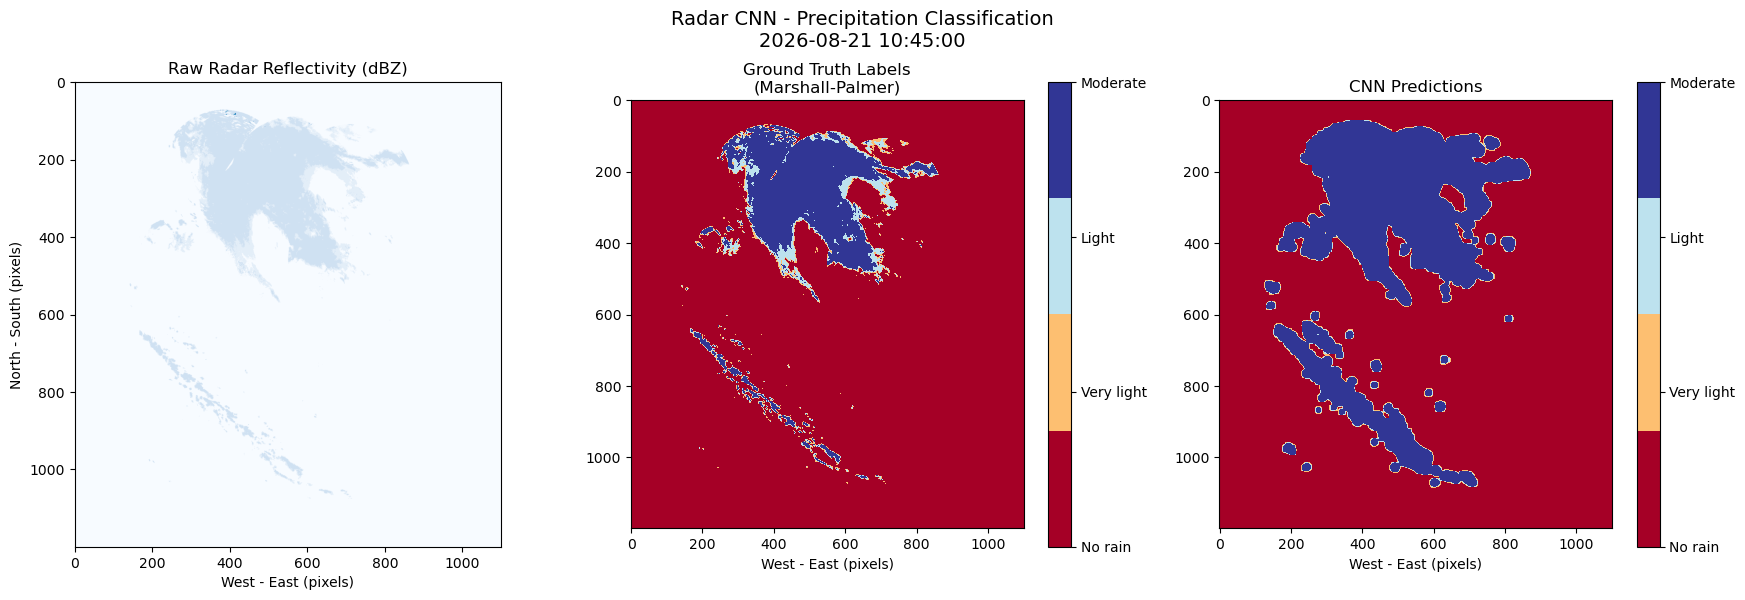


Classification Report:
                precision    recall  f1-score   support

       No rain      1.000     0.939     0.969      3612
    Very Light      0.071     0.789     0.130        19
         Light      0.573     0.891     0.698        92
Moderate+Heavy      0.978     0.901     0.938       303

      accuracy                          0.934      4026
     macro avg      0.656     0.880     0.684      4026
  weighted avg      0.984     0.934     0.956      4026



In [14]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f"Radar CNN - Precipitation Classification\n{metadata['datetime']}", fontsize=14)

# Panel 1: Raw radar
axes[0].imshow(data_clean, cmap='Blues', vmin=0, vmax=80)
axes[0].set_title('Raw Radar Reflectivity (dBZ)')
axes[0].set_xlabel('West - East (pixels)')
axes[0].set_ylabel('North - South (pixels)')

# Panel 2: Ground truth labels
cmap_labels = plt.colormaps['RdYlBu'].resampled(4)
axes[1].imshow(labels, cmap=cmap_labels, vmin=0, vmax=3)
axes[1].set_title('Ground Truth Labels\n(Marshall-Palmer)')
axes[1].set_xlabel('West - East (pixels)')
cbar1 = plt.colorbar(
    plt.cm.ScalarMappable(
        norm=plt.Normalize(0, 3),
        cmap=cmap_labels
    ), ax=axes[1], ticks=[0,1,2,3]
)
cbar1.set_ticklabels(['No rain', 'Very light', 'Light', 'Moderate'])

# Panel 3: Model predictions mapped back to image
pred_map  = np.zeros(data_clean.shape, dtype=np.float32)
count_map = np.zeros(data_clean.shape, dtype=np.float32)

model.eval()
with torch.no_grad():
    for y in range(0, data_clean.shape[0] - 16, 4):
        for x in range(0, data_clean.shape[1] - 16, 4):
            patch = data_clean[y:y+16, x:x+16]
            patch_tensor = torch.FloatTensor(
                patch / 80.0
            ).unsqueeze(0).unsqueeze(0)
            output = model(patch_tensor)
            pred   = output.argmax(dim=1).item()

            # Fill entire 16x16 region not just centre pixel
            pred_map[y:y+16, x:x+16]  += pred
            count_map[y:y+16, x:x+16] += 1

# Average overlapping predictions
count_map[count_map == 0] = 1
pred_map_final = (pred_map / count_map).astype(np.uint8)

axes[2].imshow(pred_map, cmap=cmap_labels, vmin=0, vmax=3)
axes[2].set_title('CNN Predictions')
axes[2].set_xlabel('West - East (pixels)')
cbar2 = plt.colorbar(
    plt.cm.ScalarMappable(
        norm=plt.Normalize(0, 3),
        cmap=cmap_labels
    ), ax=axes[2], ticks=[0,1,2,3]
)
cbar2.set_ticklabels(['No rain', 'Very light', 'Light', 'Moderate'])

plt.tight_layout()
plt.savefig('final_results.png', dpi=150)
plt.show()

# Print summary metrics
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=class_names_merged,
    digits=3
))